In [2]:
import pandas as pd

In [5]:
audi = pd.read_csv("../../data/02audi.csv")
titanic = pd.read_csv("../../data/titanic.csv")

# Group By

In [13]:
# Calcular cuántos hombres y mujeres hubo en el Titanic
# titanic["sex"].value_counts()

# Recuento de cada categoría de "sex" para todas las columnas
# Notar que "count" es el recuento de valores válidos
titanic.groupby("sex").count()

,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,embarked
sex,,,,,,,,,,
female,314,314,314,261,314,314,314,314,97,312
male,577,577,577,453,577,577,577,577,107,577


In [12]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    object 
 3   sex       891 non-null    object 
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    object 
 8   fare      891 non-null    float64
 9   cabin     204 non-null    object 
 10  embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [23]:
print(titanic.groupby("sex")["sex"].count()) # Recuento

print(titanic.groupby("sex")["fare"].sum()) # Suma

print(titanic.groupby("sex")["fare"].mean()) # Media

print(titanic.groupby("sex")["fare"].median()) # Median

print(titanic.groupby("sex")["fare"].std()) # Median

print(titanic.groupby("sex")["fare"].max()) # Maximo

print(titanic.groupby("sex")["fare"].min()) # Minimo

sex
female    314
male      577
Name: sex, dtype: int64
sex
female    13966.6628
male      14727.2865
Name: fare, dtype: float64
sex
female    44.479818
male      25.523893
Name: fare, dtype: float64
sex
female    23.0
male      10.5
Name: fare, dtype: float64
sex
female    57.997698
male      43.138263
Name: fare, dtype: float64
sex
female    512.3292
male      512.3292
Name: fare, dtype: float64
sex
female    6.75
male      0.00
Name: fare, dtype: float64


### Datos de Audi

- Agrupa por "model"
- Calcula precio promedio, mediana, máximo y desviación estándar

In [29]:
audi = pd.read_csv("../../data/02audi.csv")

# Agg

# audi.groupby("model")["price"].mean()

audi.groupby("model").agg({
    "price" : ["mean","count"]
})

audi.groupby("model").agg(
    precio_promedio = ("price","mean"),
    mediana = ("price", "median"),
    maximo = ("price", "max"),
    minimo = ("price", "min"),
    std = ("price", "std")
)

,precio_promedio,mediana,maximo,minimo,std
model,,,,,
A1,14327.750557,12990.0,30950,4250,4645.912222
A2,2490.000000,2490.0,2490,2490,NaN
A3,17408.522032,16995.0,36990,1490,6230.762591
A4,20255.450398,18298.0,52000,1699,8186.238490
A5,23577.114512,24686.5,59995,5495,7347.143658
A6,22695.385027,19998.0,60000,2490,9228.323578
A7,28865.516393,25995.0,53750,11440,10713.330472
A8,34981.847458,37245.0,78990,4650,11621.767292
Q2,22516.975669,21901.0,40000,12745,4031.444266


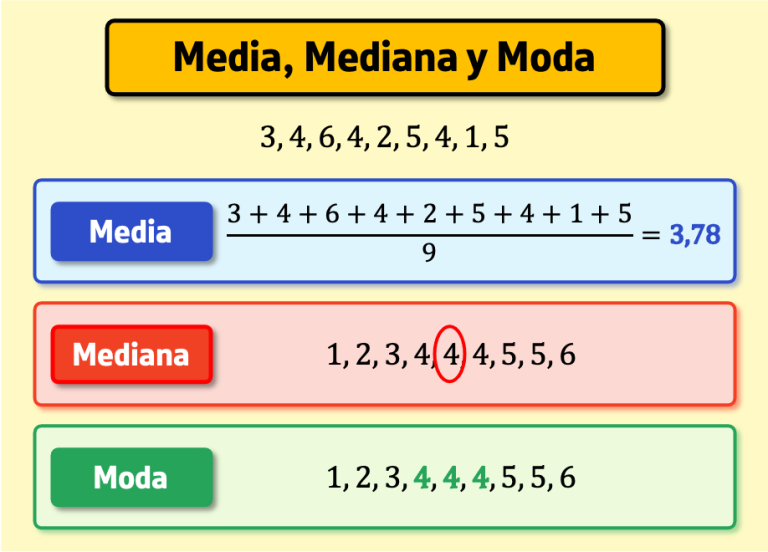

In [30]:
audi.describe()

,year,price,mileage,tax,mpg,engineSize
count,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000,10668.000000
mean,2017.100675,22896.685039,24827.244001,126.011436,50.770022,1.930709
std,2.167494,11714.841888,23505.257205,67.170294,12.949782,0.602957
min,1997.000000,1490.000000,1.000000,0.000000,18.900000,0.000000
25%,2016.000000,15130.750000,5968.750000,125.000000,40.900000,1.500000
50%,2017.000000,20200.000000,19000.000000,145.000000,49.600000,2.000000
75%,2019.000000,27990.000000,36464.500000,145.000000,58.900000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,188.300000,6.300000


### Filtra los datos de Audi por un modelo que tu eligas y utiliza describe para calcular estadísticas de ese modelo
Interpreta los resultados

In [32]:
audi_a1 = audi[audi["model"]=="A1"]
audi_a1.describe()

,year,price,mileage,tax,mpg,engineSize
count,1347.000000,1347.000000,1347.000000,1347.000000,1347.000000,1347.000000
mean,2016.626578,14327.750557,24498.288048,77.171492,58.674239,1.363920
std,1.900803,4645.912222,17963.970998,67.318207,10.995730,0.281403
min,2010.000000,4250.000000,7.000000,0.000000,39.200000,0.000000
25%,2016.000000,11000.000000,9707.500000,20.000000,51.400000,1.000000
50%,2016.000000,12990.000000,22652.000000,30.000000,56.500000,1.400000
75%,2018.000000,16994.000000,34126.000000,145.000000,67.300000,1.500000
max,2020.000000,30950.000000,116000.000000,240.000000,80.700000,2.000000


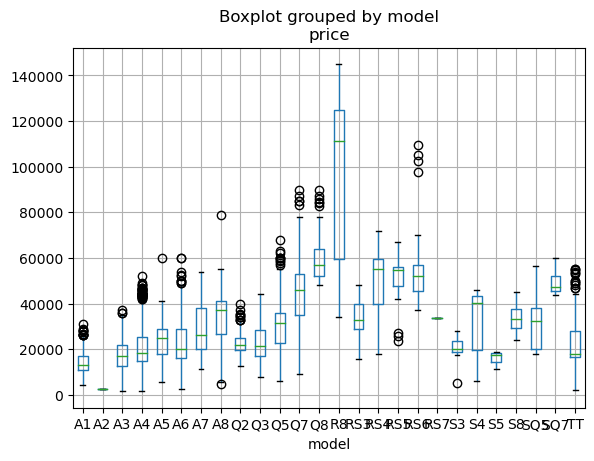

In [34]:
import matplotlib.pyplot as plt
audi.boxplot(column="price", by="model")
plt.show()

# Joins (Merge)

In [54]:
inventario = pd.DataFrame({
    "item_id": [1, 2, 3, 4],
    "nombre": ["Teclado", "Mouse", "Monitor", "Laptop"],
    "precio_unitario": [20, 10, 150, 500]
})

ventas = pd.DataFrame({
    "venta_id": [101, 102, 103, 104],
    "item_id": [1, 2, 2, 5],   # nota: el 5 no existe en inventario
    "cantidad": [2, 5, 3, 1]
})

In [49]:
inventario

,id,nombre,precio_unitario
0,1,Teclado,20
1,2,Mouse,10
2,3,Monitor,150
3,4,Laptop,500


In [50]:
ventas

,venta_id,item_id,cantidad
0,101,1,2
1,102,2,5
2,103,2,3
3,104,5,1


In [55]:
# En "merge" el join default es "inner", esto quiere decir que nos regresa sólo los registros que tienen coincidencia

# NOTA: esto quiere decir que potencialmente podemos perder filas
ventas.merge(inventario, how="inner")

,venta_id,item_id,cantidad,nombre,precio_unitario
0,101,1,2,Teclado,20
1,102,2,5,Mouse,10
2,103,2,3,Mouse,10


In [56]:
# El "left" join nos guarda todas las filas de la izquierda y regresa NA en donde no haya coincidencias
ventas.merge(inventario, how="left", on="item_id")

,venta_id,item_id,cantidad,nombre,precio_unitario
0,101,1,2,Teclado,20.0
1,102,2,5,Mouse,10.0
2,103,2,3,Mouse,10.0
3,104,5,1,NaN,NaN


In [61]:
inventario = pd.DataFrame({
    "id": [1, 2, 3, 4],
    "id_store": [1,1,1,2],
    "nombre": ["Teclado", "Mouse", "Monitor", "Laptop"],
    "precio_unitario": [20, 10, 150, 500]
})

ventas = pd.DataFrame({
    "venta_id": [101, 102, 103, 104],
    "store_id": [1,1,1,1],
    "item_id": [1, 2, 2, 5],   # nota: el 5 no existe en inventario
    "cantidad": [2, 5, 3, 1]
})

ventas.merge(inventario, how="left", left_on=["item_id","store_id"], right_on=["id","id_store"])

,venta_id,store_id,item_id,cantidad,id,id_store,nombre,precio_unitario
0,101,1,1,2,1.0,1.0,Teclado,20.0
1,102,1,2,5,2.0,1.0,Mouse,10.0
2,103,1,2,3,2.0,1.0,Mouse,10.0
3,104,1,5,1,NaN,NaN,NaN,NaN


# Apply
- Aplicar una función a cada dato de una serie

"ABC".lower()

In [62]:
"ABC".lower()

'abc'

In [63]:
for x in ["A1","A2","A3"]:
    print(x.lower())

a1
a2
a3


In [64]:
def pasar_a_minusculas(x):
    return x.lower()

In [65]:
pasar_a_minusculas("ABC")

'abc'

In [ ]:
# def limpieza_de_datos(df):
    # Detectar NAs
    # Eliminar todas las filas donde existan NAs
    # Renombar columnas
    # Hacer un group by
    # Regresar la tabla de resultados

In [81]:
def clasifica_edad(x):
    if pd.isna(x): return None

    if x>=18:
        etiqueta = "Adulto"
    else:
        etiqueta = "Menor de edad"
        
    return etiqueta


In [82]:
titanic["etiqueta"] = titanic["age"].apply(clasifica_edad)

In [84]:
titanic["etiqueta"].value_counts()

etiqueta
Adulto           601
Menor de edad    113
Name: count, dtype: int64